In [70]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Step 2: Set seaborn color palette
sns.set_palette('pastel')

# Step 3: Import wordcloud
!pip install wordcloud
from wordcloud import WordCloud

In [71]:
# Step 4: Read the file
df = pd.read_csv('data.csv')

In [76]:
# Step 5: Check head, columns, shape, info, isnull
print(df.head())

   Unnamed: 0      ID               Name  Age  \
0           0  158023           L. Messi   31   
1           1   20801  Cristiano Ronaldo   33   
2           2  190871          Neymar Jr   26   
3           3  193080             De Gea   27   
4           4  192985       K. De Bruyne   27   

                                            Photo Nationality  \
0  https://cdn.sofifa.org/players/4/19/158023.png   Argentina   
1   https://cdn.sofifa.org/players/4/19/20801.png    Portugal   
2  https://cdn.sofifa.org/players/4/19/190871.png      Brazil   
3  https://cdn.sofifa.org/players/4/19/193080.png       Spain   
4  https://cdn.sofifa.org/players/4/19/192985.png     Belgium   

                                  Flag  Overall  Potential  \
0  https://cdn.sofifa.org/flags/52.png       94         94   
1  https://cdn.sofifa.org/flags/38.png       94         94   
2  https://cdn.sofifa.org/flags/54.png       92         93   
3  https://cdn.sofifa.org/flags/45.png       91         93   
4   

In [77]:
print(df.columns)

Index(['Unnamed: 0', 'ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag',
       'Overall', 'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special',
       'Preferred Foot', 'International Reputation', 'Weak Foot',
       'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position',
       'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
       'Height', 'Weight', 'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW',
       'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM',
       'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB', 'Crossing',
       'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
       'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
       'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
       'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
       'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
       'Marking', 'StandingTackle', 'SlidingT

In [78]:
print(df.shape)

(18207, 89)


In [79]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 89 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                18207 non-null  int64  
 1   ID                        18207 non-null  int64  
 2   Name                      18207 non-null  object 
 3   Age                       18207 non-null  int64  
 4   Photo                     18207 non-null  object 
 5   Nationality               18207 non-null  object 
 6   Flag                      18207 non-null  object 
 7   Overall                   18207 non-null  int64  
 8   Potential                 18207 non-null  int64  
 9   Club                      17966 non-null  object 
 10  Club Logo                 18207 non-null  object 
 11  Value                     18207 non-null  object 
 12  Wage                      18207 non-null  object 
 13  Special                   18207 non-null  int64  
 14  Prefer

In [80]:
print(df.isnull().sum())

Unnamed: 0           0
ID                   0
Name                 0
Age                  0
Photo                0
                  ... 
GKHandling          48
GKKicking           48
GKPositioning       48
GKReflexes          48
Release Clause    1564
Length: 89, dtype: int64


<Axes: >

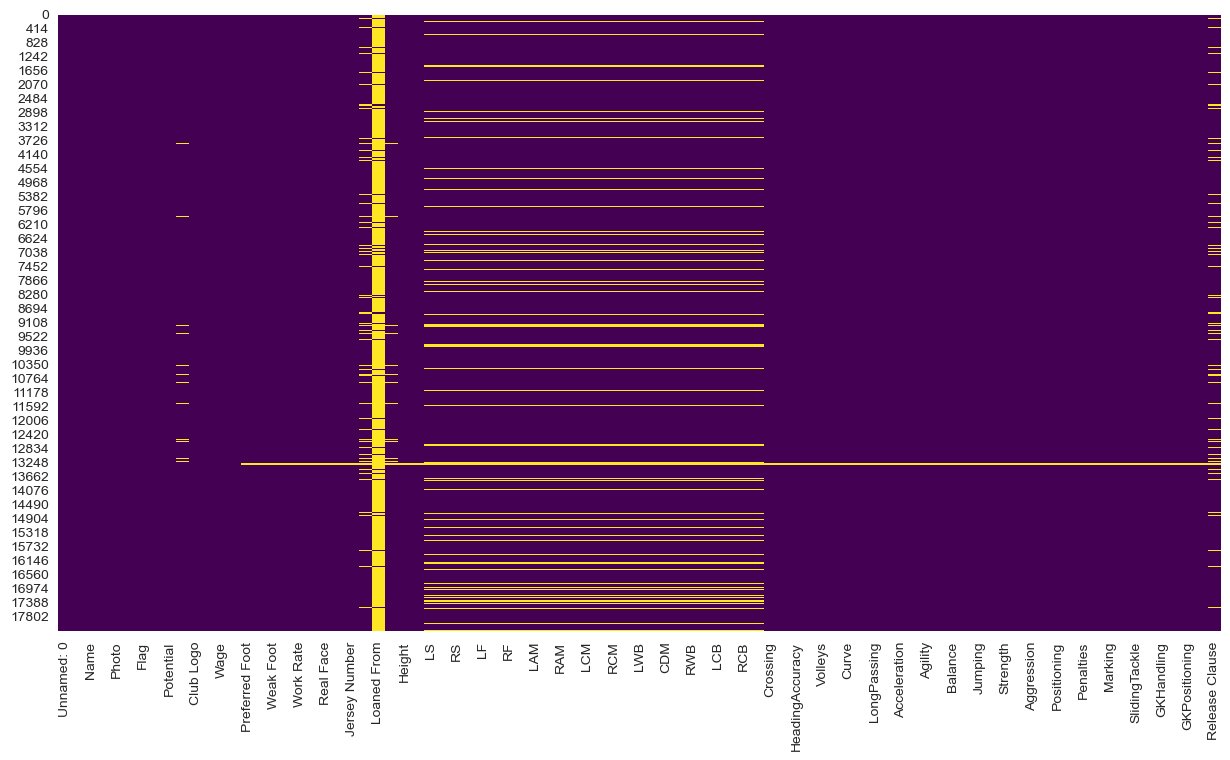

In [81]:
# Step 7: Create heatmap of missing values
plt.figure(figsize=(15,8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

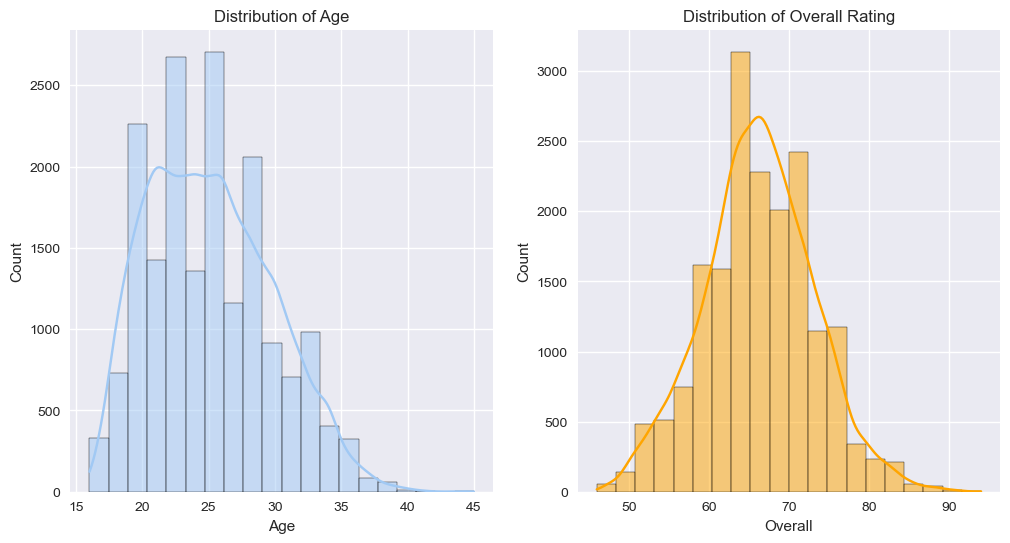

In [82]:
# Step 8: Create plots with subplots
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.subplot(1,2,2)
sns.histplot(df['Overall'], bins=20, kde=True, color='orange')
plt.title('Distribution of Overall Rating')
plt.show()

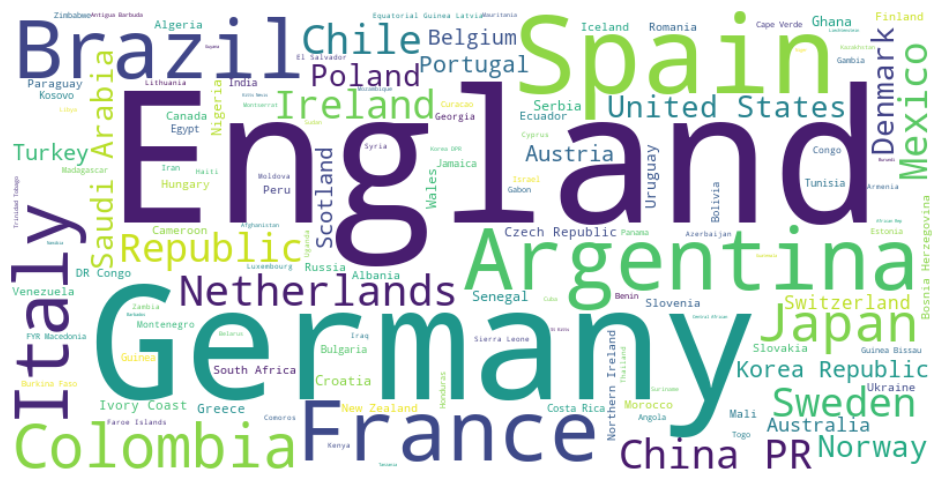

In [83]:
# Step 9: Wordcloud for Nationality
text = ' '.join(df['Nationality'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [84]:
# Step 10: Input missing values for 'Club' and 'Position'
df['Club'].fillna('Unknown', inplace=True)
df['Position'].fillna('Unknown', inplace=True)

In [85]:
# Step 11: Replace missing numerical values with mean
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

In [86]:
# Step 12: Replace categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [87]:
# Step 13: Replace 'Preferred Foot' and 'Skill Moves' missing values with median
df['Preferred Foot'].fillna(df['Preferred Foot'].mode()[0], inplace=True)
df['Skill Moves'].fillna(df['Skill Moves'].median(), inplace=True)

In [88]:

# Step 14: Remaining missing values with zero
df.fillna(0, inplace=True)

In [144]:
# Step 15: Create functions for attribute categories returning DataFrame
def create_categories(df):
    df_categories = pd.DataFrame()
    
    df_categories['General'] = df['Overall']
    
    df_categories['Shooting'] = df[['Finishing','LongShots','ShotPower','Volleys','Penalties']].mean(axis=1)
    df_categories['Passing'] = df[['ShortPassing','LongPassing','Vision','Curve','FKAccuracy','Crossing','BallControl']].mean(axis=1)
    df_categories['Mobility'] = df[['Acceleration','SprintSpeed','Agility','Reactions','Balance']].mean(axis=1)
    df_categories['Power'] = df[['Stamina','Strength','Jumping']].mean(axis=1)
    df_categories['Mental'] = df[['Positioning','Composure','Interceptions','Marking','StandingTackle','SlidingTackle','Aggression','Vision']].mean(axis=1)
    df_categories['Defending'] = df[['Marking','StandingTackle','SlidingTackle']].mean(axis=1)
    df_categories['Rating'] = df['Overall']
    
    return df_categories

# Step 16: Rename column 'Club Logo' to 'club_logo'
df.rename(columns={'Club Logo':'club_logo'}, inplace=True)

# Step 17: Add these categories to dataset in one go
df = pd.concat([df, create_categories(df)], axis=1)

In [145]:
# Step 17: Add these categories to dataset
df['General'] = df.apply(general, axis=1)
df['Shooting'] = df.apply(shooting, axis=1)
df['Passing'] = df.apply(passing, axis=1)
df['Mobility'] = df.apply(mobility, axis=1)
df['Power'] = df.apply(power, axis=1)
df['Mental'] = df.apply(mental, axis=1)
df['Defending'] = df.apply(defending, axis=1)
df['Rating'] = df.apply(rating, axis=1)

In [149]:
df.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,club_logo,...,Defending,Rating,General,Shooting,Passing,Mobility,Power,Mental,Defending,Rating
0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,...,29.000000,94,94,87.0,91.142857,91.6,66.333333,55.125,29.000000,94
1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,...,27.333333,94,94,90.8,82.142857,86.6,87.333333,55.750,27.333333,94
2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,...,28.000000,92,92,82.8,85.428571,91.6,63.666667,55.750,28.000000,92
3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,...,16.333333,91,91,21.8,38.285714,61.6,58.000000,33.125,16.333333,91
4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,...,59.000000,91,91,85.0,89.857143,80.2,76.000000,72.875,59.000000,91


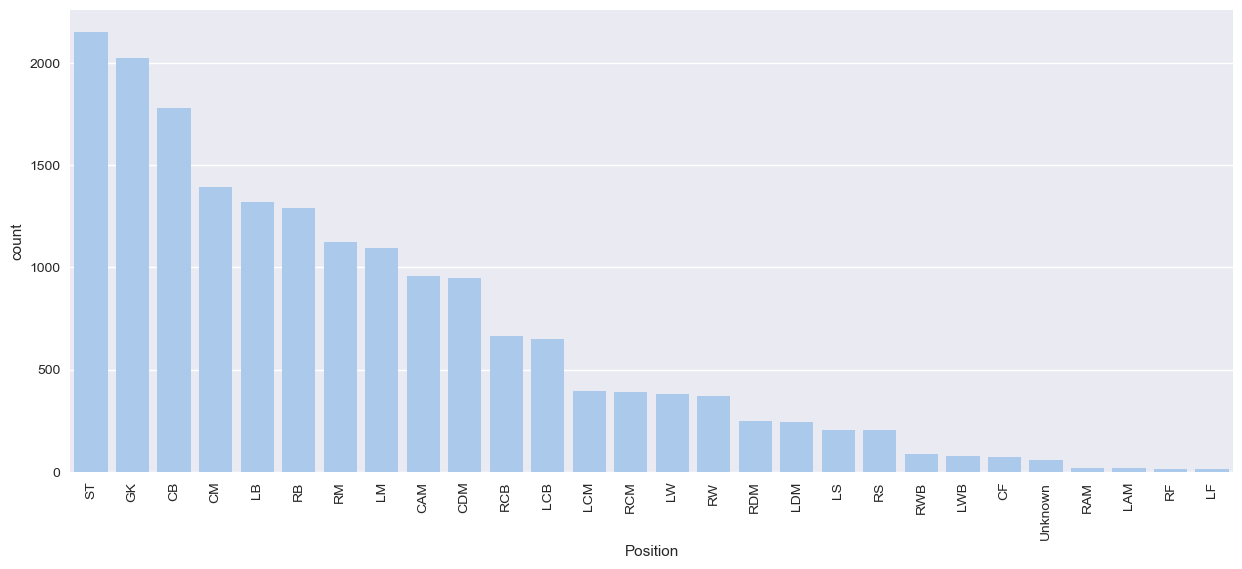

In [150]:
# Step 18: Comparison of Position and Players using countplot
plt.figure(figsize=(15,6))
sns.countplot(data=df, x='Position', order=df['Position'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

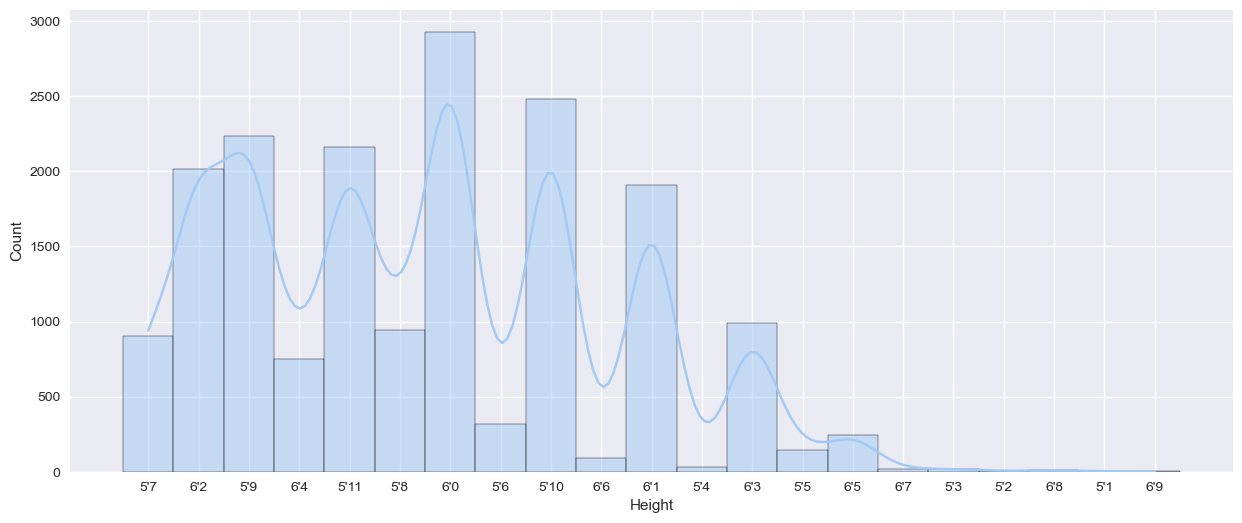

In [151]:
# Step 19: Comparison based on Height using countplot
plt.figure(figsize=(15,6))
sns.histplot(df['Height'], bins=20, kde=True)
plt.show()

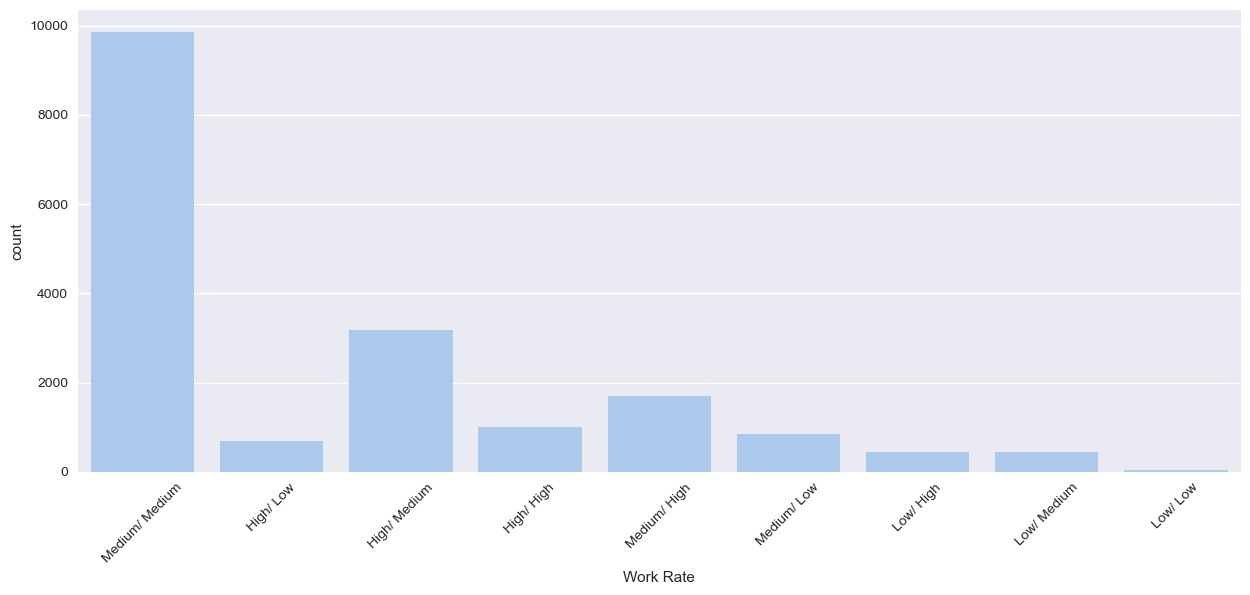

In [152]:
# Step 20: Work rate of players using countplot
plt.figure(figsize=(15,6))
sns.countplot(data=df, x='Work Rate')
plt.xticks(rotation=45)
plt.show()

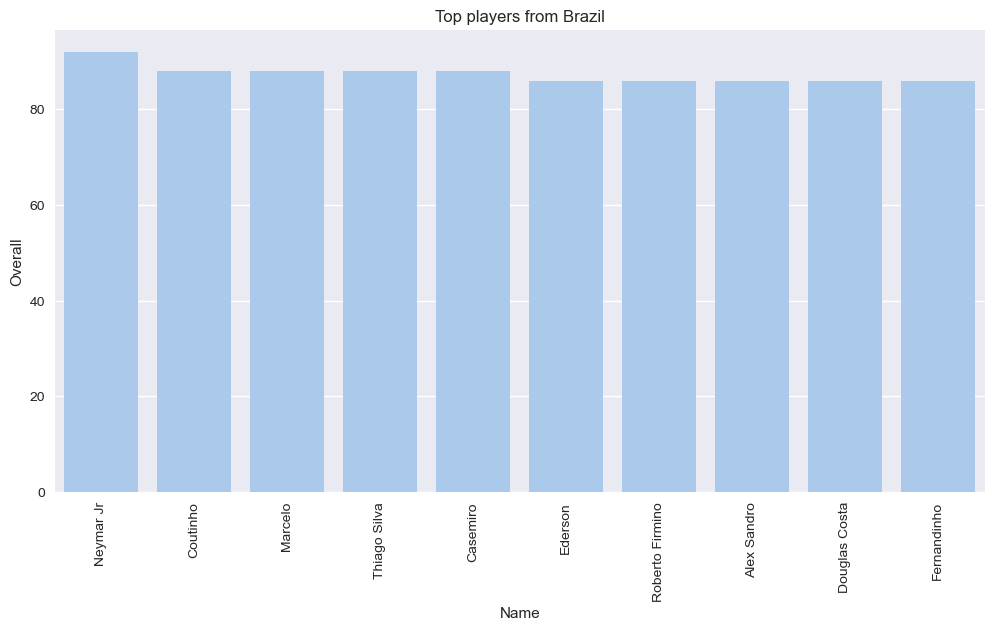

In [153]:
# Step 21: Players of some nation and their overall scores
nation = 'Brazil'
nation_df = df[df['Nationality']==nation]
plt.figure(figsize=(12,6))
sns.barplot(x='Name', y='Overall', data=nation_df.sort_values('Overall', ascending=False).head(10))
plt.xticks(rotation=90)
plt.title(f'Top players from {nation}')
plt.show()

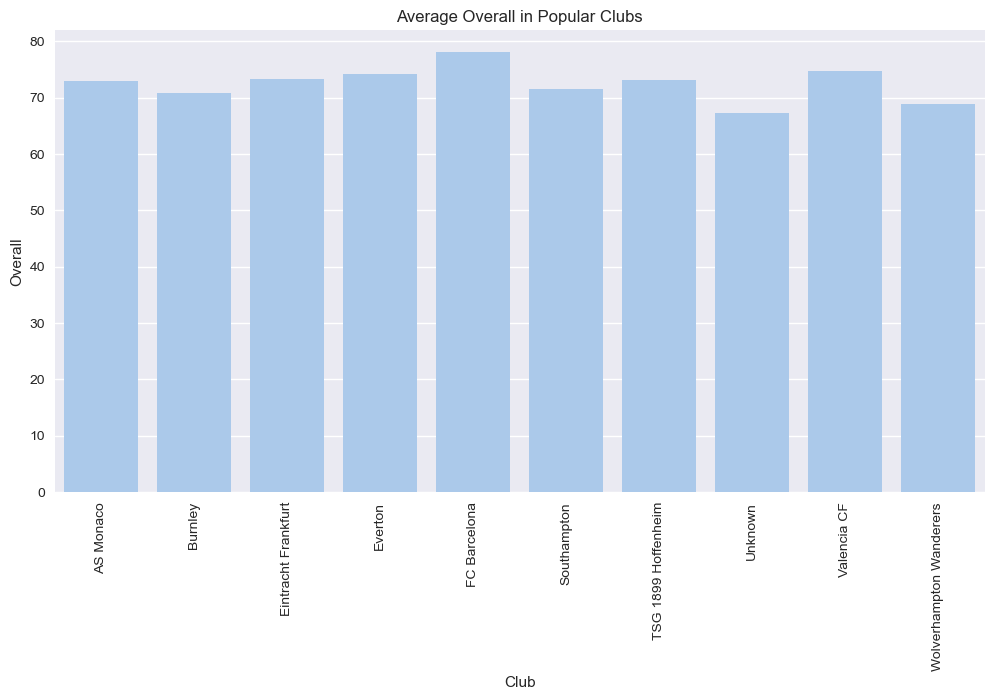

In [154]:
# Step 22: Distribution of overall score in popular clubs using barplot
popular_clubs = df['Club'].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.barplot(x='Club', y='Overall', data=df[df['Club'].isin(popular_clubs)].groupby('Club')['Overall'].mean().reset_index())
plt.xticks(rotation=90)
plt.title('Average Overall in Popular Clubs')
plt.show()

In [155]:
# Top 10 left-footed players as a DataFrame
top_left = pd.DataFrame(
    df[df['Preferred Foot'] == 'Left'][['Name', 'Age', 'Club', 'Nationality']]
    .sort_values('Age', ascending=False)
    .head(10)
)
print(top_left)

                     Name  Age                    Club   Nationality
12192        H. Sulaimani   41               Ohod Club  Saudi Arabia
3550          S. Nakamura   40            Júbilo Iwata         Japan
10356            F. Kippe   40           Lillestrøm SK        Norway
16489          K. Ellison   39               Morecambe       England
1952           P. Guiñazú   39  Club Atlético Talleres     Argentina
11456  D. Konstantopoulos   39           Middlesbrough        Greece
7427            José Juan   39                Elche CF         Spain
5101            J. Gillet   39       Standard de Liège       Belgium
4820           M. Kelemen   38   Jagiellonia Białystok      Slovakia
16628    K. Stamatopoulos   38                     AIK        Canada


In [156]:
# Top 10 right-footed players as a DataFrame
top_right = pd.DataFrame(
    df[df['Preferred Foot'] == 'Right'][['Name', 'Age', 'Club', 'Nationality']]
    .sort_values('Age', ascending=False)
    .head(10)
)
print(top_right)

                  Name  Age                          Club        Nationality
4741          O. Pérez   45                       Pachuca             Mexico
18183    K. Pilkington   44              Cambridge United            England
17726        T. Warner   44            Accrington Stanley  Trinidad & Tobago
10545      S. Narazaki   42                Nagoya Grampus              Japan
15426         M. Tyler   41           Peterborough United            England
4228          B. Nivet   41                  ESTAC Troyes             France
1120         J. Villar   41                       Unknown           Paraguay
7225          C. Muñoz   41  CD Universidad de Concepción          Argentina
9484       B. Castillo   40                Atlético Huila           Colombia
16264  P. van der Vlag   40                      FC Emmen        Netherlands


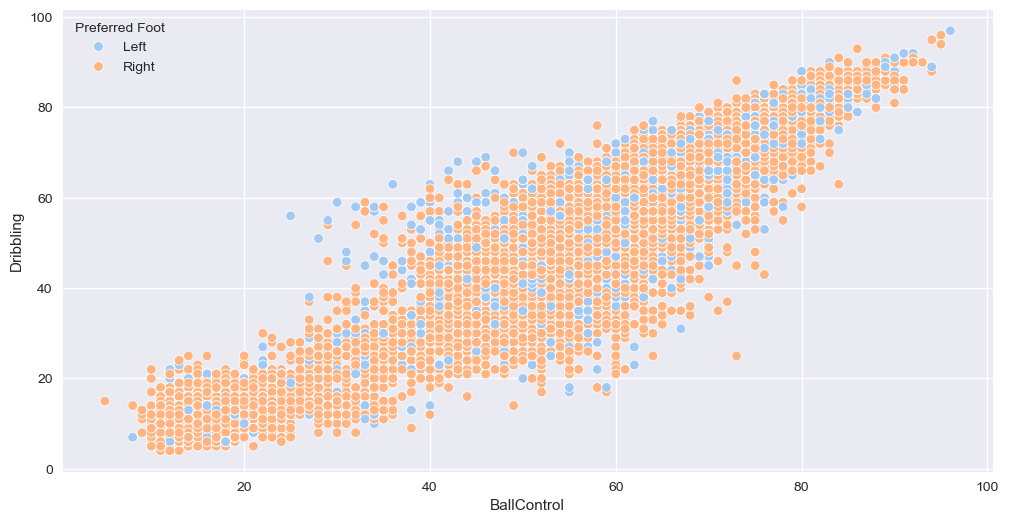

In [157]:
# Step 25: Compare ball control and dribbling of left vs right footed
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='BallControl', y='Dribbling', hue='Preferred Foot')
plt.show()

In [158]:
# Step 26: Remove 'Unnamed: 0' column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

In [159]:
# Step 27: Player with maximum potential and overall performance
max_overall = df.loc[df['Overall'].idxmax()]
max_potential = df.loc[df['Potential'].idxmax()]
print('Max Overall:', max_overall[['Name','Overall','Club']])
print('Max Potential:', max_potential[['Name','Potential','Club']])

Max Overall: Name           L. Messi
Overall              94
Club       FC Barcelona
Name: 0, dtype: object
Max Potential: Name                   K. Mbappé
Potential                     95
Club         Paris Saint-Germain
Name: 25, dtype: object


In [160]:
# Step 28: Best player for each performance criteria
criteria = ['Shooting','Passing','Mobility','Power','Mental','Defending']
for c in criteria:
    print(f"Best in {c}:")
    print(df.loc[df[c].idxmax()][['Name',c]])

Best in Shooting:
                Name  Shooting  Shooting  Shooting  Shooting  Shooting  \
1  Cristiano Ronaldo      90.8      90.8      90.8      90.8      90.8   
1  Cristiano Ronaldo      90.8      90.8      90.8      90.8      90.8   
1  Cristiano Ronaldo      90.8      90.8      90.8      90.8      90.8   
1  Cristiano Ronaldo      90.8      90.8      90.8      90.8      90.8   
1  Cristiano Ronaldo      90.8      90.8      90.8      90.8      90.8   
1  Cristiano Ronaldo      90.8      90.8      90.8      90.8      90.8   

   Shooting  
1      90.8  
1      90.8  
1      90.8  
1      90.8  
1      90.8  
1      90.8  
Best in Passing:
       Name    Passing    Passing    Passing    Passing    Passing    Passing
0  L. Messi  91.142857  91.142857  91.142857  91.142857  91.142857  91.142857
0  L. Messi  91.142857  91.142857  91.142857  91.142857  91.142857  91.142857
0  L. Messi  91.142857  91.142857  91.142857  91.142857  91.142857  91.142857
0  L. Messi  91.142857  91.142857  9

In [ ]:
# Step 30: Most frequent player names (first 20) using wordcloud
text_names = ' '.join(df['Name'].head(20))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_names)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [ ]:
# Step 31: Most mentioned club using wordcloud
text_clubs = ' '.join(df['Club'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_clubs)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()